# Week 2/3 Modeling: Tuned SVR and MLP on handoff_v3 Features

## Why we are tuning

Our initial run on the V3 features gave us **SVR: 0.6185** and **MLP: 0.5591**.

**Why did SVR beat MLP initially?**
Neural networks are only better when properly tuned. SVR came in with Week 1 parameters already optimized. The MLP was using default settings — essentially guessing. This notebook gives both models a fair shot with Grid Search.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import pearsonr
from tqdm.auto import tqdm

# --- UPDATE THIS PATH to your handoff_v3 folder on Google Drive ---
HANDOFF_DIR = "/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/ryan/handoff_v3"
W2_EXP_DIR = "/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/ryan/experiment"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Load V3 Features

In [3]:
files_to_load = [
    ('y_train_bmi.npy', HANDOFF_DIR),
    ('y_test_bmi.npy',  HANDOFF_DIR),
    ('X_train_v3_938d_pca95.npy', HANDOFF_DIR),
    ('X_test_v3_938d_pca95.npy',  HANDOFF_DIR),
]

loaded = {}
with tqdm(files_to_load, desc="Loading SVR features") as pbar:
    for fname, folder in pbar:
        pbar.set_postfix_str(fname)
        loaded[fname] = np.load(os.path.join(folder, fname))

y_train      = loaded['y_train_bmi.npy']
y_test       = loaded['y_test_bmi.npy']
X_train_938d = loaded['X_train_v3_938d_pca95.npy']
X_test_938d  = loaded['X_test_v3_938d_pca95.npy']

print(f"\nSVR features ready:")
print(f"  X_train: {X_train_938d.shape}  |  X_test: {X_test_938d.shape}")
print(f"  y_train: {y_train.shape}       |  y_test: {y_test.shape}")

# Load 4096D features for MLP
has_4096d = False
for search_dir in [HANDOFF_DIR, W2_EXP_DIR]:
    train_path = os.path.join(search_dir, 'train_features_v3_fc6.npy')
    test_path  = os.path.join(search_dir, 'test_features_v3_fc6.npy')
    if os.path.exists(train_path):
        with tqdm(total=2, desc="Loading MLP features (4096D)") as pbar:
            X_train_4096d = np.load(train_path)
            pbar.update(1)
            X_test_4096d = np.load(test_path)
            pbar.update(1)
        print(f"\nMLP features ready:")
        print(f"  X_train: {X_train_4096d.shape}  |  X_test: {X_test_4096d.shape}")
        has_4096d = True
        break

if not has_4096d:
    print("\nMLP 4096D files not found. SVR will still run. Ask Ryan for 'train_features_v3_fc6.npy'.")

Loading SVR features:   0%|          | 0/4 [00:00<?, ?it/s]


SVR features ready:
  X_train: (3210, 938)  |  X_test: (752, 938)
  y_train: (3210,)       |  y_test: (752,)


Loading MLP features (4096D):   0%|          | 0/2 [00:00<?, ?it/s]


MLP features ready:
  X_train: (3210, 4096)  |  X_test: (752, 4096)


## Step 2: Helper Functions

In [9]:
def pearson_score(y_true, y_pred):
    r, _ = pearsonr(y_true, y_pred)
    return r

def evaluate_model(y_true, y_pred, model_name):
    r, _ = pearsonr(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"Pearson r: {r:.4f}  <-- (Target: 0.6500)")
    print(f"MAE:       {mae:.4f} BMI units")
    if r >= 0.65:
        print("Beat the 0.65 target!")
    else:
        print(f"Gap to 0.65: {0.65 - r:.4f}")
    return r, mae

def manual_grid_search(model_class, param_grid, X_train, y_train, cv=3, model_label="Model"):
    """
    Runs cross-validation manually over every parameter combination.
    This gives tqdm full control over the progress bar, so you can see
    exactly how many fits are done and how long each one takes.
    """
    all_params = list(ParameterGrid(param_grid))
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    total_fits = len(all_params) * cv

    best_score = -999
    best_params = None
    results = []

    with tqdm(total=total_fits, desc=f"{model_label} Grid Search", unit="fit") as pbar:
        for params in all_params:
            fold_scores = []
            for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
                X_fold_train = X_train[train_idx]
                y_fold_train = y_train[train_idx]
                X_fold_val   = X_train[val_idx]
                y_fold_val   = y_train[val_idx]

                model = model_class(**params)
                model.fit(X_fold_train, y_fold_train)
                y_val_pred = model.predict(X_fold_val)
                score = pearson_score(y_fold_val, y_val_pred)
                fold_scores.append(score)

                # Update tqdm with current params and fold score
                pbar.set_postfix({
                    'params': str(params),
                    f'fold{fold_idx+1}_r': f"{score:.3f}"
                })
                pbar.update(1)

            mean_score = np.mean(fold_scores)
            results.append({'params': params, 'mean_cv_r': mean_score})

            if mean_score > best_score:
                best_score = mean_score
                best_params = params

    return best_params, best_score, results

print("Helper functions ready.")

Helper functions ready.


## Step 3: Grid Search for SVR

We test 9 combinations of `C` and `epsilon`, each evaluated with 3-fold cross-validation.
That is **27 total fits**. The progress bar below tracks each one.

**What these parameters do:**
- `C` controls how much the model is penalized for making large errors. Higher C = tries harder to fit every point = risk of overfitting.
- `epsilon` is the tolerance band. Predictions within `epsilon` BMI units of the true value are not penalized at all.

In [6]:
# Scale features (fit on train only, apply to both)
scaler_svr = StandardScaler()
X_train_svr = scaler_svr.fit_transform(X_train_938d)
X_test_svr  = scaler_svr.transform(X_test_938d)

print(f"After scaling - Variance: min={X_train_svr.var(axis=0).min():.4f}, max={X_train_svr.var(axis=0).max():.4f}")

param_grid_svr = {
    'C':       [1, 10, 50],
    'epsilon': [0.05, 0.1, 0.5]
}

n_svr_fits = len(list(ParameterGrid(param_grid_svr))) * 3  # 3-fold
print(f"\nStarting SVR Grid Search: {len(list(ParameterGrid(param_grid_svr)))} combos x 3 folds = {n_svr_fits} fits")

svr_grid = GridSearchCV(
    SVR(kernel='rbf', gamma='scale'),
    param_grid_svr,
    cv=3,
    scoring=pearson_scorer,
    n_jobs=-1,
    verbose=3  # verbose=3 prints each fit so you can see progress
)

start_time = time.time()
with tqdm(total=1, desc="SVR Grid Search (see verbose output above for per-fit progress)") as pbar:
    svr_grid.fit(X_train_svr, y_train)
    pbar.update(1)

elapsed = time.time() - start_time
print(f"\nSVR Grid Search complete in {elapsed/60:.1f} minutes.")
print(f"Best SVR Parameters: {svr_grid.best_params_}")
print(f"Best CV Pearson r:   {svr_grid.best_score_:.4f}")

# Evaluate on test set
y_pred_svr = svr_grid.best_estimator_.predict(X_test_svr)
r_svr, mae_svr = evaluate_model(y_test, y_pred_svr, "Tuned SVR on V3 938D")

After scaling - Variance: min=1.0000, max=1.0000

Starting SVR Grid Search: 9 combos x 3 folds = 27 fits


SVR Grid Search (see verbose output above for per-fit progress):   0%|          | 0/1 [00:00<?, ?it/s]

Fitting 3 folds for each of 9 candidates, totalling 27 fits

SVR Grid Search complete in 2.0 minutes.
Best SVR Parameters: {'C': 10, 'epsilon': 0.5}
Best CV Pearson r:   0.5439

=== Tuned SVR on V3 938D ===
Pearson r: 0.6182  <-- (Target: 0.6500)
MAE:       5.4377 BMI units
Gap to 0.65: 0.0318


## Step 4: Grid Search for MLP

We test 18 combinations across architecture, regularization, and learning rate.
That is **54 total fits**. Each fit trains a neural network for up to 150 epochs with early stopping.

**What these parameters do:**
- `hidden_layer_sizes`: The shape of the network. `(512, 128)` means two hidden layers with 512 and 128 neurons.
- `alpha`: L2 regularization. Penalizes large weights to prevent overfitting. Higher = simpler model.
- `learning_rate_init`: How big each update step is. Too high = unstable. Too low = slow convergence.

In [12]:
if not has_4096d:
    print("4096D files not found. Skipping MLP. Ask Ryan for 'train_features_v3_fc6.npy'.")
else:
    scaler_mlp = StandardScaler()
    X_train_mlp = scaler_mlp.fit_transform(X_train_4096d)
    X_test_mlp  = scaler_mlp.transform(X_test_4096d)

    param_grid_mlp = {
        'hidden_layer_sizes': [(512,), (512, 128), (256, 64)],
        'alpha':              [0.001, 0.01, 0.1],
        'learning_rate_init': [0.001, 0.0005],
        'activation':         ['relu'],
        'solver':             ['adam'],
        'max_iter':           [150],
        'early_stopping':     [True],
        'random_state':       [42]
    }

    start_time = time.time()
    best_mlp_params, best_mlp_cv_r, mlp_results = manual_grid_search(
        MLPRegressor, param_grid_mlp, X_train_mlp, y_train, cv=3, model_label="MLP"
    )

    print(f"\nMLP Grid Search complete in {(time.time()-start_time)/60:.1f} minutes.")
    print(f"Best MLP Parameters: {best_mlp_params}")
    print(f"Best CV Pearson r:   {best_mlp_cv_r:.4f}")

    # Train final model on full training set with best params
    final_mlp = MLPRegressor(**best_mlp_params)
    with tqdm(total=1, desc="Training final MLP on full training set") as pbar:
        final_mlp.fit(X_train_mlp, y_train)
        pbar.update(1)

    y_pred_mlp = final_mlp.predict(X_test_mlp)
    r_mlp, mae_mlp = evaluate_model(y_test, y_pred_mlp, "Tuned MLP on V3 4096D")

MLP Grid Search:   0%|          | 0/54 [00:00<?, ?fit/s]


MLP Grid Search complete in 12.1 minutes.
Best MLP Parameters: {'activation': 'relu', 'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (512, 128), 'learning_rate_init': 0.001, 'max_iter': 150, 'random_state': 42, 'solver': 'adam'}
Best CV Pearson r:   0.6301


Training final MLP on full training set:   0%|          | 0/1 [00:00<?, ?it/s]


=== Tuned MLP on V3 4096D ===
Pearson r: 0.5750  <-- (Target: 0.6500)
MAE:       5.4788 BMI units
Gap to 0.65: 0.0750


## Step 5: Summary and Visualization

FINAL TUNED RESULTS SUMMARY
Paper baseline (target):  r = 0.6500
Previous SVR (untuned):   r = 0.6185
Previous MLP (untuned):   r = 0.5591
Tuned SVR (938D):         r = 0.6182  |  MAE = 5.44
Tuned MLP (4096D):        r = 0.5750  |  MAE = 5.48


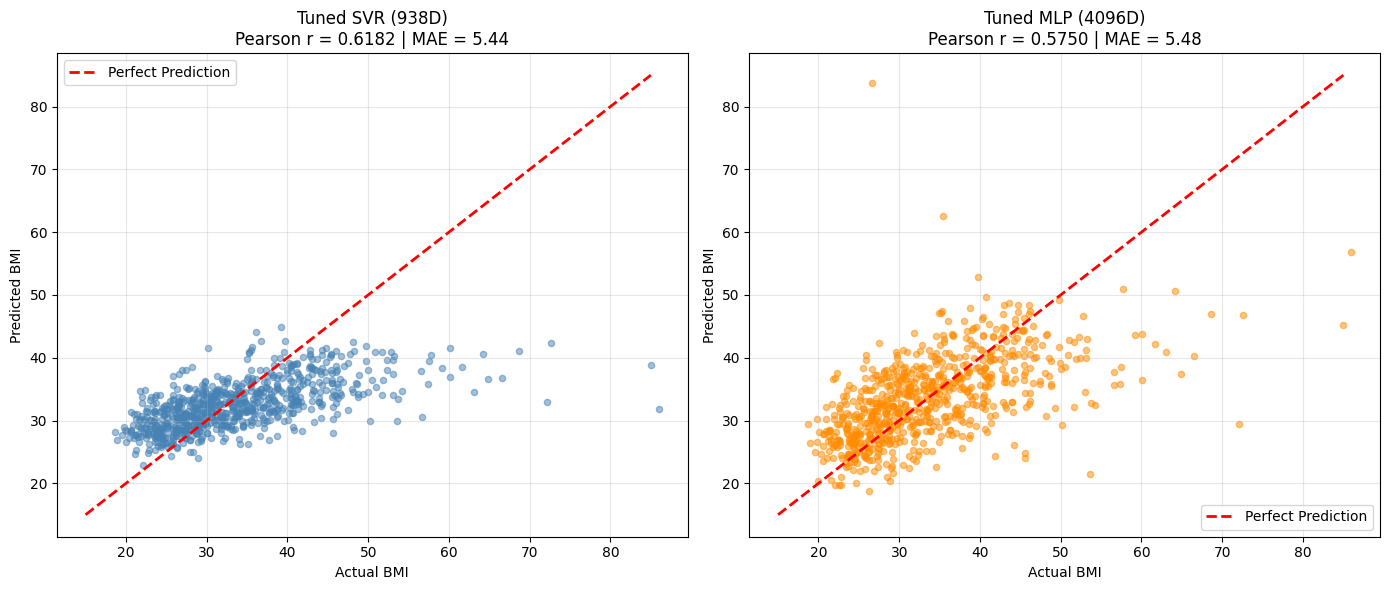

Saved as 'tuned_v3_comparison.png'


In [13]:

print("FINAL TUNED RESULTS SUMMARY")

print(f"Paper baseline (target):  r = 0.6500")
print(f"Previous SVR (untuned):   r = 0.6185")
print(f"Previous MLP (untuned):   r = 0.5591")
print(f"Tuned SVR (938D):         r = {r_svr:.4f}  |  MAE = {mae_svr:.2f}")
if has_4096d:
    print(f"Tuned MLP (4096D):        r = {r_mlp:.4f}  |  MAE = {mae_mlp:.2f}")


ncols = 2 if has_4096d else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
if ncols == 1:
    axes = [axes]

axes[0].scatter(y_test, y_pred_svr, alpha=0.5, color='steelblue', s=20)
axes[0].plot([15, 85], [15, 85], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f"Tuned SVR (938D)\nPearson r = {r_svr:.4f} | MAE = {mae_svr:.2f}")
axes[0].set_xlabel("Actual BMI")
axes[0].set_ylabel("Predicted BMI")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if has_4096d:
    axes[1].scatter(y_test, y_pred_mlp, alpha=0.5, color='darkorange', s=20)
    axes[1].plot([15, 85], [15, 85], 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_title(f"Tuned MLP (4096D)\nPearson r = {r_mlp:.4f} | MAE = {mae_mlp:.2f}")
    axes[1].set_xlabel("Actual BMI")
    axes[1].set_ylabel("Predicted BMI")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tuned_v3_comparison.png', dpi=150)
plt.show()
print("Saved as 'tuned_v3_comparison.png'")